# Project 1: LHC anomaly detection challenge

**Dataset:** https://uwmadison.box.com/s/702f3xsndlbpc18ud54vemewku63uypg

**Grading:**
These projects will be peer-graded using the rubric listed below. 

**Deadline:** 
The project will be due by class time on Monday, October 6th at 4:00pm Central Time. Please upload a `zip` file to Canvas of the following: 
- Your completed notebook (`.ipynb` format)
- Your completed notebook (`.html` format)
- A PDF of an extended abstract, written in LaTeX and no more than 2 pages in length, introducing the problem, summarizing your methods and work, reflecting on your results, listing what future work you would explore, and showing at least one figure. You may use any LaTeX format you like, including 2-column layouts if you prefer. 

## Project description
In this project, you will analyze a dataset consisting of 1 million simulated LHC dijet events for which some number of events correspond to a new, Beyond-the-Standard-Model particle. Below you will find some basic imports and plotting style code as well as instructions on how to load the dataset. Your job is to design an analysis that is able to detect this resonant anomaly in a data-driven manner using weakly-supervised anomaly detection. 

## Additional resources
- https://journals.aps.org/prd/pdf/10.1103/PhysRevD.99.014038
- https://arxiv.org/pdf/2101.08320

In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### ML-related imports
import torch 
import torch.nn as nn
from torch.utils.data import Dataset, TensorDataset, DataLoader
from livelossplot import PlotLosses

### plotting_setup 
%config InlineBackend.figure_format = 'retina'

plt.rcParams['figure.figsize'] = (9,6)

medium_size = 12
large_size = 15

plt.rc('font', size=medium_size)          # default text sizes
plt.rc('xtick', labelsize=medium_size)    # xtick labels
plt.rc('ytick', labelsize=medium_size)    # ytick labels
plt.rc('legend', fontsize=medium_size)    # legend
plt.rc('axes', titlesize=large_size)      # axes title
plt.rc('axes', labelsize=large_size)      # x and y labels
plt.rc('figure', titlesize=large_size)    # figure title

The dataset consists of 14 variables, for the highest-momentum jet (j1) and the second-highest momentum jet (j2): 
- The jet mass: $m_j$
- The 3-momenta: $p_x$, $p_y$, $p_z$
- 3 variables characterizing the jet substructure ("$n$-subjettiness"): $\tau_1$, $\tau_2$, and $\tau_3$

In [11]:
df = pd.read_hdf("data.h5")
df

,pxj1,pyj1,pzj1,mj1,tau1j1,tau2j1,tau3j1,pxj2,pyj2,pzj2,mj2,tau1j2,tau2j2,tau3j2
317331,-1111.069946,522.442017,114.790001,95.897903,59.727699,36.523300,29.496099,1067.829956,-400.492004,-77.473297,297.545990,181.567993,32.994801,28.694401
382230,-484.207001,-1099.430054,46.311298,180.507004,86.382698,55.473301,36.421600,484.061005,912.642029,-2837.260010,149.589996,83.781502,46.721500,42.142101
778429,1184.270020,804.263000,-293.928986,221.714005,101.822998,82.812698,59.080601,-628.812012,-765.088013,415.691010,34.022598,11.589900,8.191830,5.358200
441210,-1269.520020,181.677002,248.542007,681.546997,596.260986,140.774994,124.349998,1121.739990,-75.208504,1612.750000,126.462997,86.812103,36.044498,26.255800
260227,1242.500000,1341.780029,618.713989,372.934998,274.535004,83.173302,58.498798,-259.114014,-1157.680054,-2724.270020,189.709000,143.147995,42.135201,39.118599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591130,-1295.030029,249.735992,786.190002,134.509995,40.363499,22.352900,17.923300,1172.369995,-226.207993,-750.036011,114.856003,65.127899,29.753201,22.493099
331817,-1221.069946,297.638000,-112.454002,168.151001,112.366997,42.945202,24.415800,914.945984,-58.493099,1931.969971,107.008003,55.022301,49.527401,35.817501
58122,-750.086975,-1005.169983,-173.414993,447.487000,382.514008,158.860001,119.383003,743.752014,823.197021,-252.216995,80.689697,31.891800,20.190500,15.565200
503729,143.149002,1271.300049,422.515015,204.789993,124.416000,61.448799,48.163700,86.303703,-527.780029,-2351.969971,140.785004,114.289001,31.138800,23.750401


We will first calculate the invariant mass of the combined 2 jets to understand the general shape of the data:

In [4]:
def get_mjj(df): 
    E1 = np.sqrt(df.pxj1**2 + df.pyj1**2 + df.pzj1**2 + df.mj1**2)
    E2 = np.sqrt(df.pxj2**2 + df.pyj2**2 + df.pzj2**2 + df.mj2**2)
    
    Ex = df.pxj1 + df.pxj2
    Ey = df.pyj1 + df.pyj2
    Ez = df.pzj1 + df.pzj2
    E  = E1 + E2
    return np.sqrt(np.maximum(E**2 - (Ex**2 + Ey**2 + Ez**2), 0.0))

df["m_jj"] = get_mjj(df)

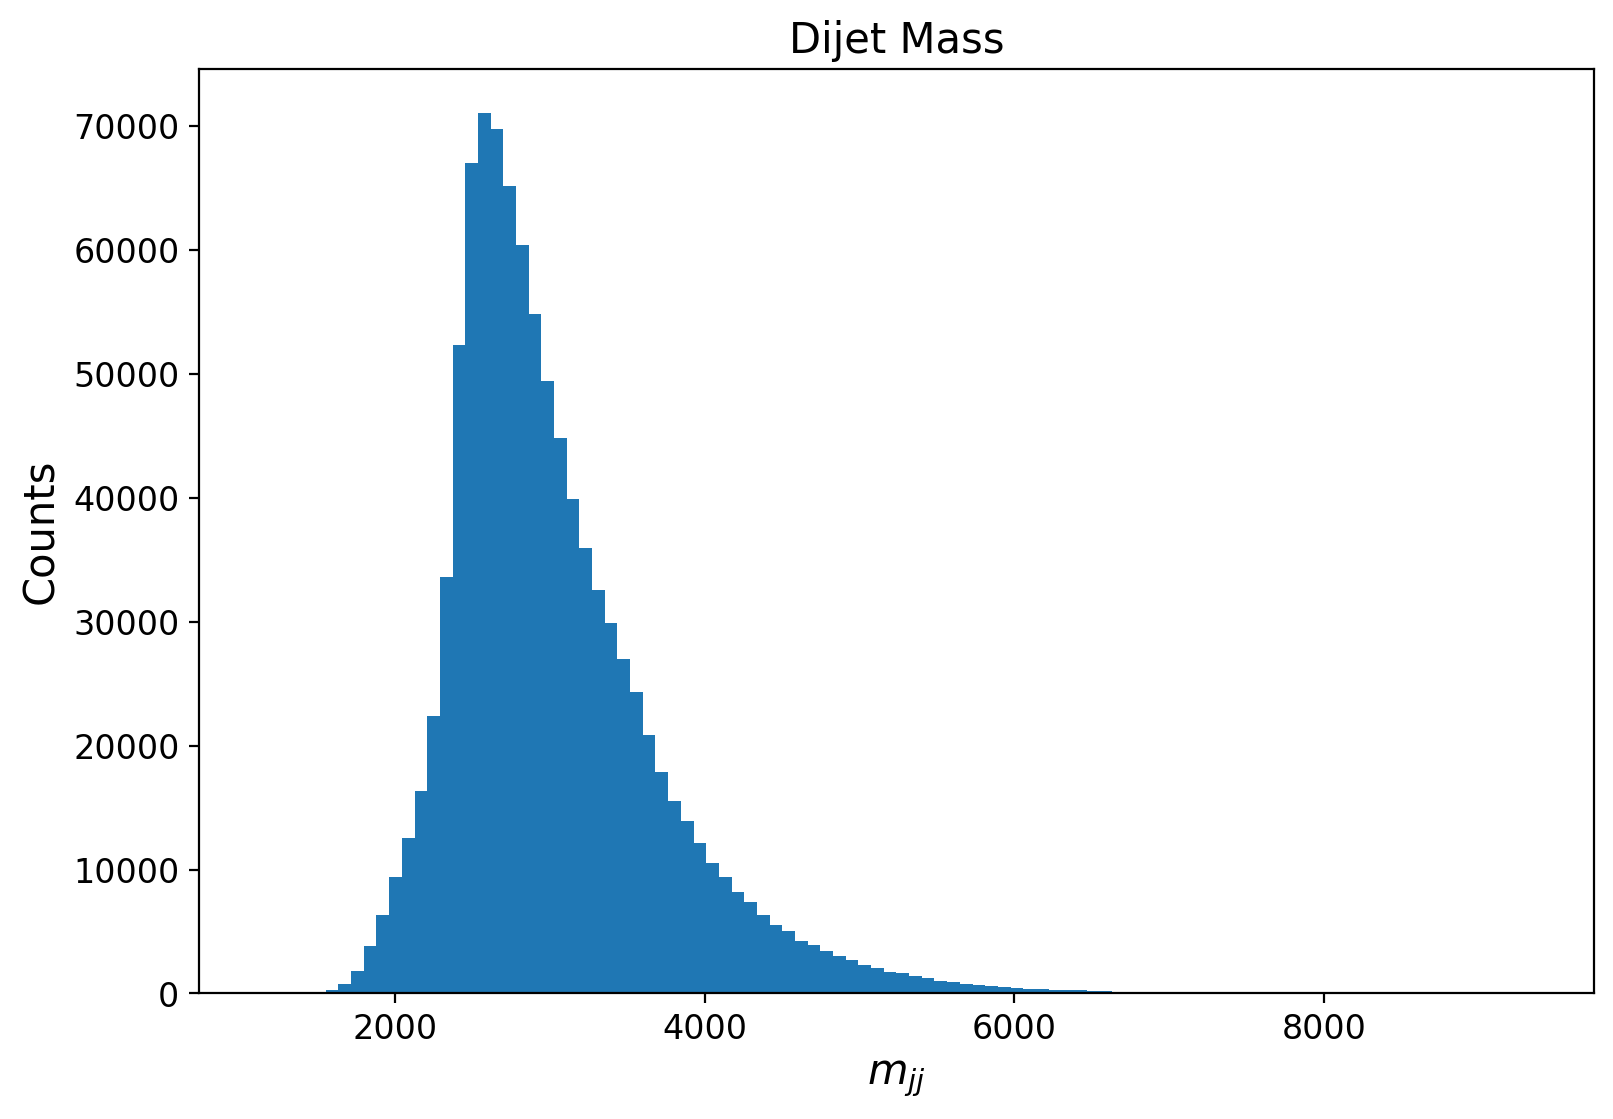

In [5]:
plt.hist(df.m_jj,bins=100);
plt.xlabel(r"$m_{jj}$");
plt.ylabel("Counts");
plt.title("Dijet Mass");

# First steps: 

### Set up your weakly-supervised analysis: 
- Which values of $m_{jj}$ will you scan over? Keep in mind that you want to only look in regions where your background is smoothly falling. You will train several models in a sliding-window fashion.
- As a starting point, let your sideband regions be 100 GeV wide each and your signal region be 200 GeV wide.
- Apply signal (1) and background (0) labels to events based on these signal and sideband definitions.

### Preprocess your data: 
- Choose training variables (start with one, then add more)
- Split into train/validation/test sets
- Scale your datasets using $z$-scores
- Define DataLoader objects for your train/val/test sets

### Define your model & train
- Define an MLP with 3 hidden layers and ReLU activations
- Print the number of trainable parameters and verify that the number of training events is at least 10 times the number of trainable parameters (a sometimes helpful rule-of-thumb)
- Select binary cross-entropy loss and Adam optimizer
- Train for around 10-20 epochs
- Visualize the loss curves

### Evaluate your model 
- Evaluate your trained model on the test set
- Visualize the events assigned high scores
- Do they look like a bump?
- If so, fit a Gaussian distribution to these events and extract the median value
- Report this as the mass of your newly-discovered particle

### Continue the scan 
Pick a new region of $m_{jj}$ and repeat the steps above. 

# Next steps:

- As you continue your scan, what pattern is emerging? Do your results make sense?
- The weakly-supervised anomaly detection paradigm requires that your training variables are **uncorrelated** with the variable you use to select your search window, i.e. $m_{jj}$. Check to see if any of your input variables are correlated with $m_{jj}$ (and think about how $m_{jj}$ is calculated).  
- If any of your input variables are correlated with $m_{jj}$, consider either removing them, *or* think about how you might remove this correlation so that you can still use these variables during training. (*Hint:* Consult the papers listed in "Additional Resources" above for some suggestions on how to do this.)
- Once you have properly de-correlated your input variables, re-try your scan. You should expect to largely see null results, i.e. your classifier model should not be able to tell the difference between signal & sideband samples *except* when it has found a true anomaly.
- Can you find the anomalous region in this dataset? What is the average mass of the resonant bump you find in the $m_{jj}$ spectrum? Can you report an error band as well?

# Going deeper: 

Experiment with at least one of your own modifications to this method. 

Consider: 
- Playing more with input variables
- Trying different decorrelation methods
- Modifying the classifier architecture
- Tweaking hyperparameters
- Implementing a cross-validation strategy
- Ensembling your results across multiple independent trainings
- Reporting a $p$-value or significance ($\sigma$) as a function of $m_{jj}$
- Compare your performance with an unsupervised method like an autoencoder

---

# Peer Review Grading Rubric

For full credit on this open-ended task, you are expected to: 
- Develop & implement a procedure for finding anomalies using weakly-supervised learning methods
- Use sufficient documentation in your code for an external reader to understand your methods and why you chose them
- Write up your results in a short extended abstract in LaTeX, no more than 2 pages in length, including at least one figure.

### You will be graded using the following rubric:

- **5/5 points: Fully complete** Completed the full analysis with documented code, an extended abstract PDF written in LaTeX, showing sensible plots and a clear bump in $m_{jj}$ with an extracted average mass value and uncertainty. They have also made their own extension of the method using at least one of the bullet points listed under "Going Deeper". 

- **4/5 points: Almost complete** All the pieces are there, but e.g. the extended abstract is very short, the code is minimally documented, or no extensions are included from the "Going Deeper" list. 

- **3/5 points: About halfway complete** The analysis has been attempted but is missing one or two major portions, although there is some documentation of the code throughout. 

- **2/5 points: Partially Incomplete** Attempt at an analysis, missing one or two major pieces of the technical work, and documentation is minimal to nonexistent.

- **1/5 points: Incomplete** Missing several major pieces of the technical work (e.g. no progress on "Next Steps" section) and little to no explanation

- **0/5 points: Missing** No work or progress on the project